<a href="https://colab.research.google.com/github/AliceSantoro/Kohonen/blob/main/kohonen_1D_over_2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rete di Kohonen con topologia 1D su uno spazio a 2D



## Caricamento dei moduli necessari

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.animation as animation
import random
from tqdm import tqdm # progress bar

## Punti di ancoraggio
Definizione di funzioni che generano un certo numero di punti in uno spazio 2D con diverse distribuzioni:

-Distribuzione uniforme su un `disco` o su un `tringolo` in due dimensioni

-`spirale`



In [ ]:
def disk(r,n):
    rs = np.sqrt(np.random.uniform(0,r**2,n))
    thetas = np.random.uniform(0,2*np.pi,n)
    xs = rs*np.cos(thetas)
    ys = rs*np.sin(thetas)
    return xs,ys

In [ ]:
def triangle(v1,v2,v3,n):
    xs = []
    ys = []
    for i in range(n):
        # Generate random barycentric coordinates
        r1 = random.uniform(0, 1)
        r2 = random.uniform(0, 1 - r1)

        # Calculate corresponding point in triangle
        x = r1 * v1[0] + r2 * v2[0] + (1 - r1 - r2) * v3[0]
        y = r1 * v1[1] + r2 * v2[1] + (1 - r1 - r2) * v3[1]
        xs.append(x)
        ys.append(y)
    return xs,ys


In [ ]:
def generate_spiral_points(num_points):
  xs = []
  ys = []
  angle_step = 0.1
  radius_step = 0.1
  angle = 0
  radius = 0
  for i in range(num_points):
        x = radius * math.cos(angle)
        y = radius * math.sin(angle)
        xs.append(x)
        ys.append(y)
        angle += angle_step
        radius += radius_step
  return xs,ys


## Parametri

`n` neuroni, `m` punti di esempio. I neuroni devono essere **meno** dei punti di esempio, per evitare l'overfitting.

In [ ]:
n = 400
m = 500

## Genero le coordinate x e y per `m` punti con la distribuzione che ho scelto



In [ ]:
e_x,e_y = generate_spiral_points(m)

In [ ]:
e_x,e_y = disk(1.0,m)

In [ ]:
pt1 = (1, 1)
pt2 = (2, 4)
pt3 = (5, 2)
e_x,e_y = triangle(pt1,pt2,pt3,m)

##Plot scatter dei punti

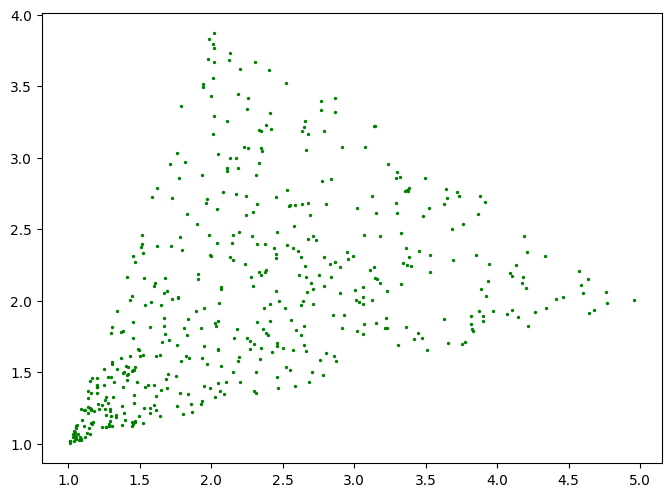

In [ ]:

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(aspect='equal')
ax.scatter(e_x,e_y,c='g',s=2)


## Genero il reticolo discreto unidimensionale di neuroni

I punti sono a 2 dimensioni, quindi mi servono `n` coordinate in 2D, che chiamo  `w_x` e `w_y`. La topologia e' a 1 dimensione, quindi le `w_x`, `w_y` sono 1D (vettori)



In [ ]:
w_x = 0.1*np.random.rand(n)
w_y = 0.1*np.random.rand(n)

## Rappresentazione della rete prima dell'apprendimento


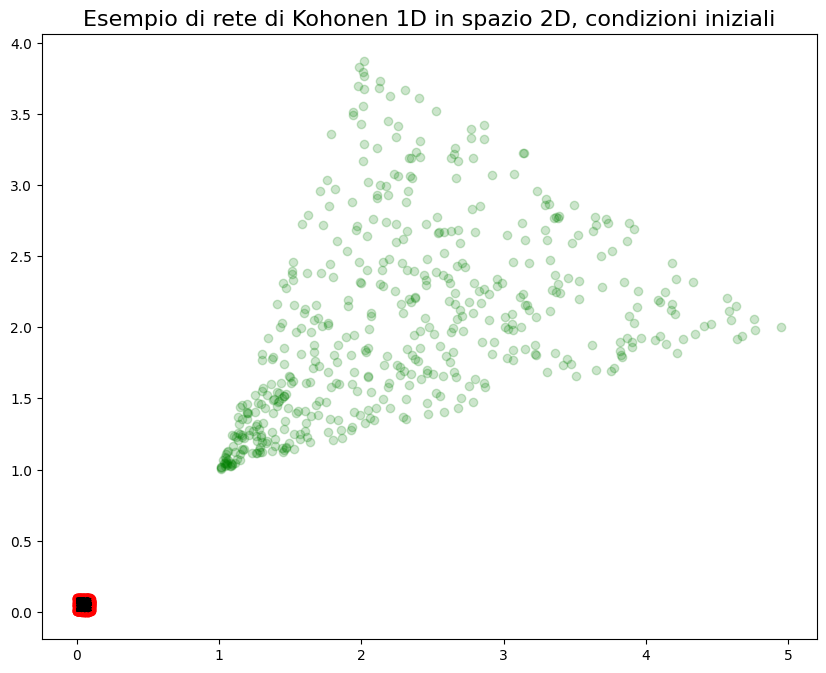

In [ ]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(aspect='equal')
ax.scatter(e_x,e_y, c='g',alpha=0.2)
ax.scatter(w_x,w_y, c='r',marker='o')
ax.plot(w_x,w_y,'k',linewidth=1)
ax.set_title('Esempio di rete di Kohonen 1D in spazio 2D, condizioni iniziali',fontsize=16)
plt.show()

## Ottimizzazione (training) della rete

In [ ]:
# scelgo il numero di passi di apprendimento
# 1 step = 1000 updates
nsteps = 100

eps0=0.15
sigma0=18

# alloco dello spazio per salvare i pesi ad ogni step
w_x_t = np.empty((n,nsteps),dtype=float)
w_y_t = np.empty_like(w_x_t)

#%%
print("\n**** Training iniziato !!! ****\n")

# initial conditions at step 0

w_x_t[:,0] = w_x
w_y_t[:,0] = w_y

# apprendimento dal primo step in avanti
for _t in tqdm(range(nsteps-1)):
    eps = eps0 * (0.99**_t)
    sigma = sigma0 * (0.96**_t)
    t = _t+1 # prossimo timestep
    # inizializzo dal timestep precedente
    w_x_t[:,t] = w_x_t[:,t-1]
    w_y_t[:,t] = w_y_t[:,t-1]
    # somministro 1000 punti di esempio per ogni passo
    for _ in range(1000):
      # scelgo randomicamente un punto di esempio
      exi = np.random.randint(m)
      # calcolo la matrice delle distanze
      dist = ((e_x[exi]-w_x_t[:,t])**2 +
              (e_y[exi]-w_y_t[:,t])**2 )
      # trovo l'indice del neurone vincitore
      ineigh = np.argmin(dist, axis=None)

       # faccio l'updatedi TUTTI i pesi
      for i in range(n):
        f_up=np.exp(-((i-ineigh)**2)/(2*sigma**2))
        w_x_t[i,t]=w_x_t[i,t]+eps*f_up*(e_x[exi]-w_x_t[i,t])
        w_y_t[i,t]=w_y_t[i,t]+eps*f_up*(e_y[exi]-w_y_t[i,t])

print(f"\n**** Training completato per {nsteps} steps ****\n")


**** Training iniziato !!! ****



100%|██████████| 99/99 [04:16<00:00,  2.60s/it]


**** Training completato per 100 steps ****



## Rete allo stato finale

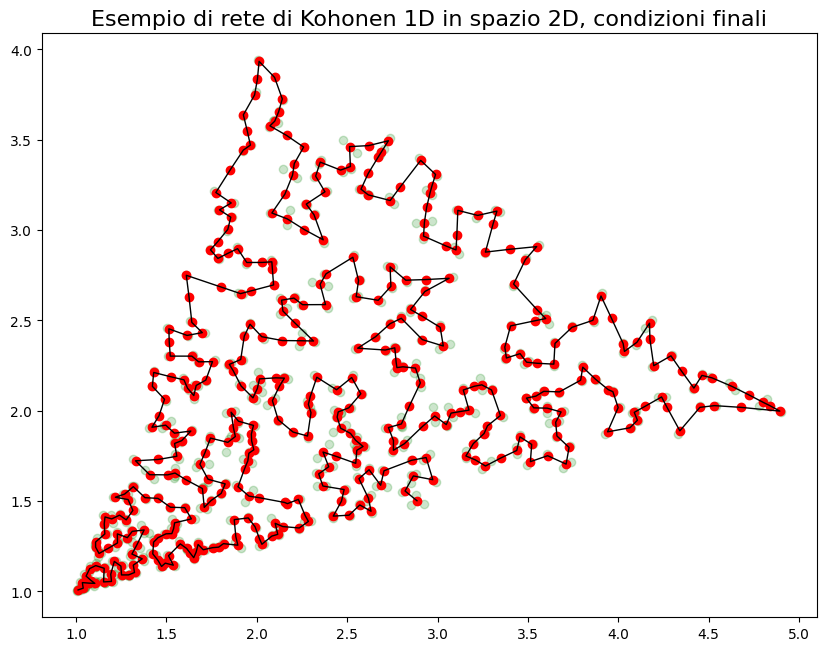

In [ ]:

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(aspect='equal')
ax.scatter(e_x,e_y, c='g',alpha=0.2)
ax.scatter(w_x_t[:,-1],w_y_t[:,-1], c='r',marker='o')
ax.plot(w_x_t[:,-1],w_y_t[:,-1],'k',linewidth=1)
ax.set_title("Esempio di rete di Kohonen 1D in spazio 2D, condizioni finali",fontsize=16)
plt.show()

## Animazione dell'evoluzione della rete

Il filmato viene salvato nel file '/content/kohonen_1D_over2D.mp4', disponibile nell'elenco file a sinistra.



**** Generando l'animazione  ****


*** Animazione completa ***



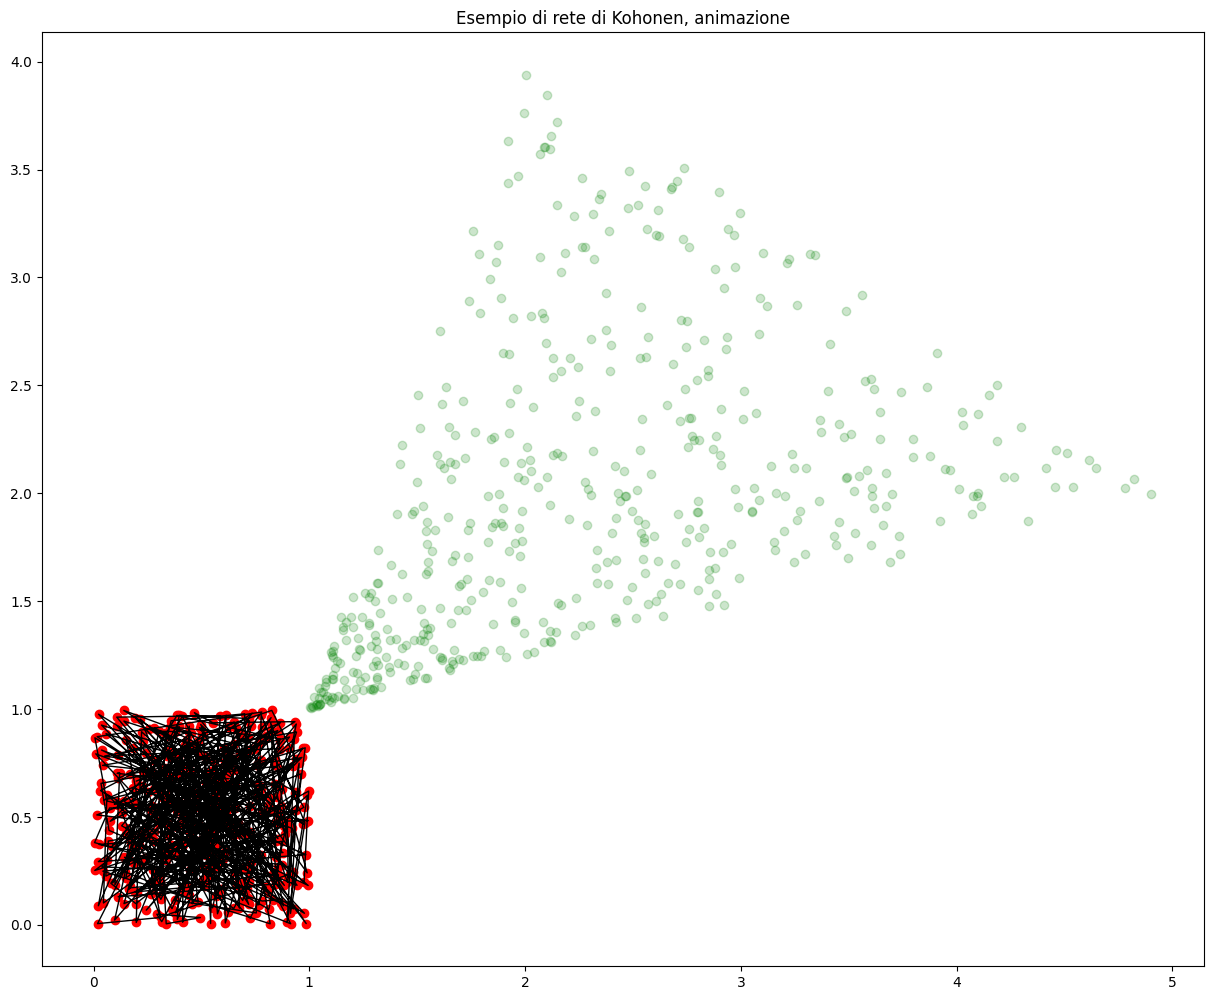

In [ ]:
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(aspect='equal')

nframes =  w_x_t.shape[1]

def update_figure(k):
    w_xp = w_x_t[:,k]
    w_yp = w_y_t[:,k]
    # draw the network
    ax.clear()
    ax.scatter(e_x,e_y, c='g',alpha=0.2)
    ax.scatter(w_x_t[:,k],w_y_t[:,k], c='r',marker='o')
    ax.plot(w_x_t[:,k],w_y_t[:,k],'k',linewidth=1)
    ax.set_title("Esempio di rete di Kohonen, animazione")
    return ax

#%%
print("\n**** Generando l'animazione  ****\n")

anim = animation.FuncAnimation(fig, func=update_figure, frames=nframes,
                               repeat=False);

# create a video writer
writervideo = animation.FFMpegWriter(fps=7)
anim.save('/content/kohonen_1D_over2D.mp4', writer=writervideo)
# %%
print("\n*** Animazione completa ***\n")